In [45]:
#Reading csv file into dataframe
import pandas as pd

df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,56,male,27.12,2,no,northeast,22092.71
1,46,female,29.50,1,no,northwest,16089.85
2,32,male,26.07,5,no,southeast,22901.99
3,60,male,30.90,1,no,northwest,28010.56
4,25,male,26.91,0,no,northeast,11805.37


In [46]:
#Checking for null values
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [47]:
#General EDA
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [48]:
#General EDA
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,41.036622,30.547668,1.067265,24361.613625
std,13.528861,5.968852,1.232187,10045.233825
min,18.000000,15.960000,0.000000,4168.200000
25%,29.000000,26.432500,0.000000,17758.582500
50%,42.000000,30.720000,1.000000,22226.660000
75%,52.000000,34.610000,2.000000,27249.772500
max,64.000000,47.360000,5.000000,59205.820000


In [49]:
#typecasting
df[['sex', 'smoker', 'region']] = df[['sex', 'smoker', 'region']].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       1338 non-null   int64   
 1   sex       1338 non-null   category
 2   bmi       1338 non-null   float64 
 3   children  1338 non-null   int64   
 4   smoker    1338 non-null   category
 5   region    1338 non-null   category
 6   charges   1338 non-null   float64 
dtypes: category(3), float64(2), int64(2)
memory usage: 46.3 KB


In [50]:
from sklearn.preprocessing import LabelBinarizer

#encoding categorical columns
df_reg = df.copy()

#ecoding smoker as binary
df_reg['smoker_bin'] = (df_reg['smoker'] == 'yes').astype(int)
df_reg= df_reg.drop('smoker', axis= 1)

#encoding sex, region
df_reg = pd.get_dummies(df_reg, columns= ['sex', 'region'], drop_first=True, dtype=int)

df_reg.head()

,age,bmi,children,charges,smoker_bin,sex_male,region_northwest,region_southeast,region_southwest
0,56,27.12,2,22092.71,0,1,0,0,0
1,46,29.50,1,16089.85,0,0,1,0,0
2,32,26.07,5,22901.99,0,1,0,1,0
3,60,30.90,1,28010.56,0,1,1,0,0
4,25,26.91,0,11805.37,0,1,0,0,0


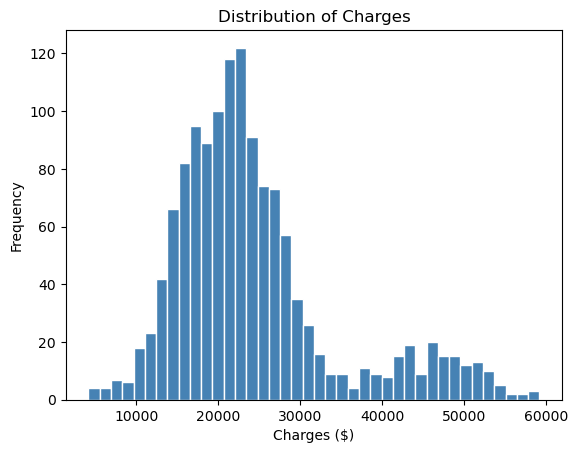

In [51]:
# Distribution of charges
import matplotlib.pyplot as plt
plt.hist(df['charges'], bins=40, color='steelblue', edgecolor='white')
plt.title('Distribution of Charges')
plt.xlabel('Charges ($)')
plt.ylabel('Frequency')
plt.show()

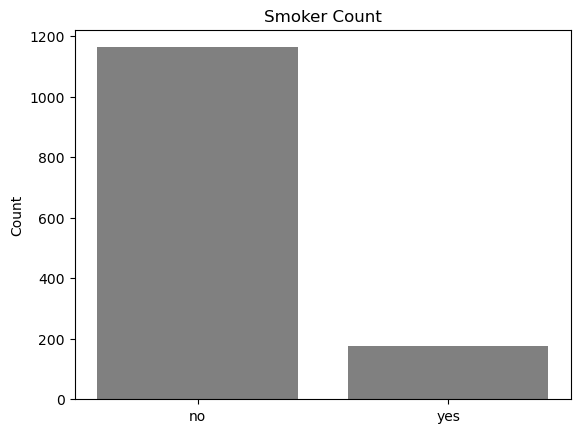

In [52]:
# Smoker count
smoker_counts = df['smoker'].value_counts()
plt.bar(smoker_counts.index, smoker_counts.values, color='grey')
plt.ylabel('Count')
plt.title('Smoker Count')
plt.show()

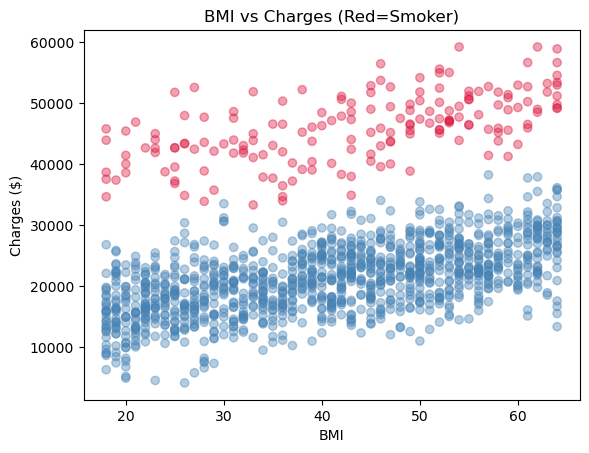

In [53]:
# BMI vs Charges coloured by smoker
colors = df['smoker'].map({'yes': 'crimson', 'no': 'steelblue'})
plt.scatter(df['age'], df['charges'], c=colors, alpha=0.4)
plt.title('BMI vs Charges (Red=Smoker)')
plt.xlabel('BMI')
plt.ylabel('Charges ($)')
plt.show()

In [54]:
#Task 2
#Splitting into training and testing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
X_reg = df_reg.drop('charges', axis=1)
y_reg = df_reg['charges']

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size= 0.2, random_state= 42)

print("Training samples: ", X_train.shape[0])
print("Testing samples: ", X_test.shape[0])

Training samples:  1070
Testing samples:  268


In [55]:
#Setting up the baseline model
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)

baseline_pred= baseline.predict(X_test)

print("Baseline R²  :", round(r2_score(y_test, baseline_pred), 4))
print("Baseline RMSE:", round(np.sqrt(mean_squared_error(y_test, baseline_pred)), 2))

Baseline R²  : -0.0009
Baseline RMSE: 10230.18


In [56]:
#linear regression model to predict charges using features in the dataset
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred =lin_reg.predict(X_test)

R2 = r2_score(y_test, y_pred)
RMSE = np.sqrt(mean_squared_error(y_test, y_pred))

print("R-square: ", R2)
print("RMSE: ", RMSE)

R-square:  0.8501591479521758
RMSE:  3958.220578615298


In [57]:
#We can see that our regression model is definitely an improvement on our baseline

In [58]:

coef_df = pd.DataFrame({
    'Feature': X_reg.columns,
    'Coefficient': lin_reg.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"Intercept: ${lin_reg.intercept_:,.2f}")
print()
print(coef_df.to_string(index=False))

Intercept: $453.53

         Feature  Coefficient
      smoker_bin 24154.541231
        children   606.024630
             bmi   335.639222
             age   236.184084
        sex_male   233.788952
region_northwest   131.046586
region_southeast   -79.936142
region_southwest   -59.806143


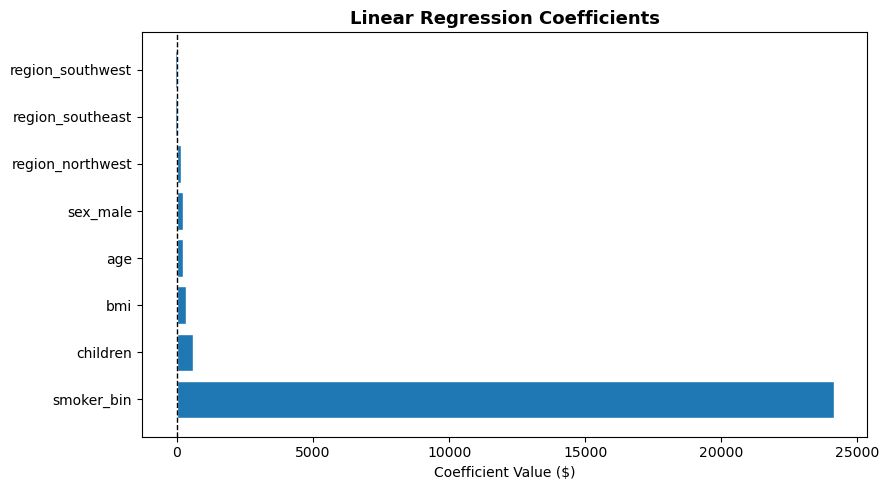

In [59]:
# ── Coefficient Plot ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(coef_df['Feature'], coef_df['Coefficient'], edgecolor='white')
ax.axvline(0, color='black', linewidth=1, linestyle='--')
ax.set_title('Linear Regression Coefficients', fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient Value ($)')
plt.tight_layout()
plt.show()


In [60]:
"""Top 3 predictors
- Smoker(24154.54), number of children(606.02) and bmi(335.64) are the top influencers of the prediction of cost of insurance with
smoker being the highest"""

""" The intercept in this case represents the baseline charge given that all other features don't have any influence and are turned to zero which 
does not have any real world value to us here and is just used to anchor the regression plane"""

" The intercept in this case represents the baseline charge given that all other features don't have any influence and are turned to zero which \ndoes not have any real world value to us here and is just used to anchor the regression plane"

In [61]:
#Task 3
#Predicting if a customer is a smoker or not
df_cls = df.copy()
df_cls.head()

,age,sex,bmi,children,smoker,region,charges
0,56,male,27.12,2,no,northeast,22092.71
1,46,female,29.50,1,no,northwest,16089.85
2,32,male,26.07,5,no,southeast,22901.99
3,60,male,30.90,1,no,northwest,28010.56
4,25,male,26.91,0,no,northeast,11805.37


In [62]:
#ecoding smoker as binary
df_cls['smoker_bin'] = (df_cls['smoker'] == 'yes').astype(int)

# One-hot encode sex and region
df_cls = pd.get_dummies(df_cls, columns=['sex', 'region'], drop_first=True, dtype=int)
df_cls = df_cls.drop('smoker', axis=1)
df_cls.head()



,age,bmi,children,charges,smoker_bin,sex_male,region_northwest,region_southeast,region_southwest
0,56,27.12,2,22092.71,0,1,0,0,0
1,46,29.50,1,16089.85,0,0,1,0,0
2,32,26.07,5,22901.99,0,1,0,1,0
3,60,30.90,1,28010.56,0,1,1,0,0
4,25,26.91,0,11805.37,0,1,0,0,0


In [63]:
#smoker distribution
X_cls = df_cls.drop('smoker_bin', axis=1)
y_cls = df_cls['smoker_bin']

print(y_cls.value_counts().rename({0: 'Non-Smoker', 1: 'Smoker'}))

print(f"\nFeatures used: {X_cls.columns.tolist()}")

smoker_bin
Non-Smoker    1163
Smoker         175
Name: count, dtype: int64

Features used: ['age', 'bmi', 'children', 'charges', 'sex_male', 'region_northwest', 'region_southeast', 'region_southwest']


In [64]:
#Train/test split

X_train, X_test, y_train, y_test= train_test_split( X_cls, y_cls, test_size=0.2, random_state=42)

print("Training samples: ", X_train.shape[0])
print("Testing samples: ", X_test.shape[0])

Training samples:  1070
Testing samples:  268


In [65]:
#Logistic Regression
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, mean_squared_error, r2_score,
    precision_recall_curve, average_precision_score, confusion_matrix
)

logit= LogisticRegression(max_iter=1000, random_state=42)
logit.fit(X_train, y_train)

y_pred= logit.predict(X_test)
y_proba = logit.predict_proba(X_test)[:, 1]

#Model evaluations
accuracy = round(accuracy_score(y_test, y_pred), 4)
Precision = round(precision_score(y_test, y_pred, zero_division=0), 4)
Recall = round(recall_score(y_test, y_pred, zero_division=0), 4)

print("Accuracy: ", accuracy)
print("Precision: ", Precision)
print("Recall: ", Recall)


Accuracy:  0.9963
Precision:  1.0
Recall:  0.9722


In [66]:
#Naive bayes
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)

y_pred= model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

#Model evaluations
accuracy = round(accuracy_score(y_test, y_pred), 4)
Precision = round(precision_score(y_test, y_pred, zero_division=0), 4)
Recall = round(recall_score(y_test, y_pred, zero_division=0), 4)

print("Accuracy: ", accuracy)
print("Precision: ", Precision)
print("Recall: ", Recall)


Accuracy:  0.9851
Precision:  0.9706
Recall:  0.9167


In [67]:
#Discriminant Analysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

model = LinearDiscriminantAnalysis()
model.fit(X_train, y_train)

y_pred= model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

#Model evaluations
accuracy = round(accuracy_score(y_test, y_pred), 4)
Precision = round(precision_score(y_test, y_pred, zero_division=0), 4)
Recall = round(recall_score(y_test, y_pred, zero_division=0), 4)

print("Accuracy: ", accuracy)
print("Precision: ", Precision)
print("Recall: ", Recall)

Accuracy:  0.9963
Precision:  1.0
Recall:  0.9722


Average Precision Score: 1.0000


(0.0, 1.05)

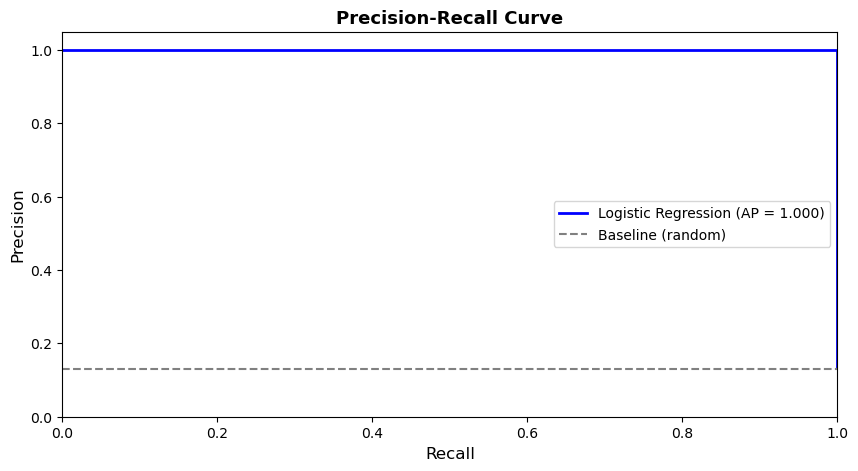

In [68]:
#Task 4
#Best Model: Logistic Regression
import seaborn as sns
import matplotlib.pyplot as plt

best_model = logit
y_proba_best = best_model.predict_proba(X_test)[:, 1]

# Compute Precision-Recall curve
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_proba_best)
avg_precision = average_precision_score(y_test, y_proba_best)

print(f"Average Precision Score: {avg_precision:.4f}")

# Plot 1: Precision-Recall Curve
fig, axes = plt.subplots(1, 1, figsize=(10, 5))
axes.plot(recall_vals, precision_vals, color='blue', lw=2,
             label=f'Logistic Regression (AP = {avg_precision:.3f})')
axes.axhline(y=y_cls.mean(), color='gray', linestyle='--', label='Baseline (random)')
axes.set_xlabel('Recall', fontsize=12)
axes.set_ylabel('Precision', fontsize=12)
axes.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
axes.legend()
axes.set_xlim([0, 1])
axes.set_ylim([0, 1.05])

In [71]:
# Finding the Optimal Threshold (maximize F1)
f1_scores = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals)
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best threshold: {best_threshold:.2f}")



Best threshold: 0.30


In [72]:
# Applying the best threshold
y_pred_custom = (y_proba >= best_threshold).astype(int)

# Evaluate with new threshold
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       232
           1       1.00      0.97      0.99        36

    accuracy                           1.00       268
   macro avg       1.00      0.99      0.99       268
weighted avg       1.00      1.00      1.00       268

